In [1]:
from dataclasses import dataclass
import numpy as np
import os
import random
import torch
import torchvision.transforms as transforms

if not os.path.exists("./KuiSCIMA"):
    !git clone https://github.com/SuziAI/KuiSCIMA.git
if not os.path.exists("./gui-tools"):
    !git clone https://github.com/SuziAI/gui-tools.git

from data_extraction import *
from image_manipulation import *
from model import *
from lvlvpu import *

BATCH_SIZE = 100

In [2]:
# Extract data from KuiSCIMA dataset
extract_data()

# Set seeds
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

In [3]:
total_dataset = open_lvlvpu_dataset("./TotalDataset/Music/")
total_dataset = get_cropped_dataset(total_dataset, remove_blobs=False)

## Normalizes the dataset to have mean 0 and standard deviation of 1
mean_list = torch.Tensor([torch.Tensor(entry["image"]).mean() for entry in total_dataset])/255
mean = mean_list.mean()
std = mean_list.std()

def normalize():
    return transforms.Normalize(mean=mean, std=std)

def get_train_transforms(image_size=48):
    target_shrink = image_size - 4
    target_paste = image_size
    train_transforms = transforms.Compose([
        erode(percentage=0.2), # causes the notation to be thicker
        dilate(percentage=0.2), # causes the notation to be thinner
        transforms.ToTensor(), # convert from uint8 to [0, 1]
        shrink(is_random=True, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        salt_and_pepper(percentage=0.8), # introduces salt-and-pepper-noise
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        transforms.RandomRotation(degrees=(-9, 9)), # randomly rotate between -12 and 12 degrees
        #lambda img: transforms.functional.invert(img), # inverts image to original color scheme
        normalize(), # normalize mean and variance
    ])
    return train_transforms


def get_validation_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    validation_transforms = transforms.Compose([
        transforms.ToTensor(),
        shrink(is_random=False, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        normalize(), # normalize mean and variance
    ])
    return validation_transforms


def get_test_transforms(image_size=48):
    return get_validation_transforms(image_size=image_size)

transformations = {
    "train": get_test_transforms,
    "validation": get_test_transforms,
    "test": get_test_transforms
}

# Temperature Scaling

In [6]:
def predict_data_loader(model, data_loader, scaled=True):
    model.eval()  
    predictions = []
    labels = []  
    with torch.no_grad():  
        for batch in data_loader:
            images = batch[0]
            
            if scaled:
                probs = model.forward(images)
            else:
                probs = model.forward_unscaled(images)
                
            predictions.extend(probs.cpu().numpy())
            labels.extend(batch[1].cpu().numpy())  
    return torch.from_numpy(np.array(predictions)), torch.from_numpy(np.array(labels))


def reliability_diagram(output, true_labels, n_bins=10, name="", plot=True):
    bins = torch.linspace(0, 1, n_bins + 1)
    bin_lowers = bins[:-1]
    bin_uppers = bins[1:]

    accuracies = torch.zeros(n_bins)
    confidences = torch.zeros(n_bins)
    bin_counts = torch.zeros(n_bins)
    
    max_output = output.max(dim=1)
    predicted_confidences = max_output.values
    predicted_labels = max_output.indices

    def get_bin(conf):
        for idx, bin_upper in enumerate(bin_uppers):
            if conf < bin_upper:
                return idx
        return n_bins-1
    
    bin_to_idx = {}
    for bin_number in range(n_bins):
        bin_to_idx[bin_number] = []
    
    for idx, pred_conf in enumerate(predicted_confidences):
        bin_to_idx[get_bin(pred_conf)].append(idx)
    
    for bin_number in range(n_bins):
        bin_idxs = bin_to_idx[bin_number]
        bin_counts[bin_number] = len(bin_idxs)
        if len(bin_idxs) > 0:
            correct = (true_labels[bin_idxs] == predicted_labels[bin_idxs]).float()
            accuracies[bin_number] = correct.mean()
            confidences[bin_number] = predicted_confidences[bin_idxs].mean()

    if plot:
        plt.figure(figsize=(12, 5))
        plt.suptitle(name)
    
        # Reliability diagram
        plt.subplot(1, 2, 1)
        plt.plot([0, 1], [0, 1], 'k--')
        plt.plot(confidences, accuracies, marker='o')
        plt.xlabel('Confidence')
        plt.ylabel('Accuracy')
        plt.title('Reliability Diagram')
    
        # Histogram 
        plt.subplot(1, 2, 2)
        plt.bar(bin_lowers, bin_counts, width=(bin_uppers[1] - bin_lowers[1]), align='edge', edgecolor='k')
        plt.xlabel('Confidence')
        plt.ylabel('Number of Samples')
        plt.title('Confidence Histogram')
    
        plt.tight_layout()
        plt.savefig(f"{name}.pdf", format="pdf", bbox_inches="tight")
        plt.show()

    # Compute ECE
    valid_bins = bin_counts > 0  # Only consider non-empty bins
    ece = torch.sum(bin_counts[valid_bins] / bin_counts.sum() * torch.abs(accuracies[valid_bins] - confidences[valid_bins]))
    return ece.item()*100

In [7]:
MODEL_FOLDER = "lvlvpu_models"
label_type = "full"

In [42]:


ece_results = {}
for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
    ece_results[test_edition] = {}
    print(test_edition)
    print("    ", label_type)
    ece_results[test_edition] = {}
    ece_results[test_edition]["uncalibrated"] = []
    ece_results[test_edition]["calibrated"] = []

    for trial in range(10):
        print("         ", trial)
        model = CnnModel(num_classes = 17)
        total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, test_edition=test_edition, is_suzipu=False)
        
        model.load_state_dict(torch.load(f"{MODEL_FOLDER}/lvlvpu-best-{test_edition}.std"))
        calibration_module_pitch = TemperatureScalingCalibrationModule(model)
        calibration_module_pitch.freeze_base_model()
        calibration_module_pitch.fit(total_dataloaders[label_type]["validation"], start_value=1., lr=0.05, n_epochs=5)
    
        output, labels = predict_data_loader(calibration_module_pitch, total_dataloaders[label_type]["test"], scaled=False)
        ece_results[test_edition]["uncalibrated"].append(reliability_diagram(output, labels, name="Suzipu Pitch (Uncalibrated)", plot=False))
        output, labels = predict_data_loader(calibration_module_pitch, total_dataloaders[label_type]["test"], scaled=True)
        ece_results[test_edition]["calibrated"].append(reliability_diagram(output, labels, name="Suzipu Pitch (Calibrated)", plot=False))

lu
     full
          0
          1
          2
          3
          4
          5
          6
          7
          8
          9
zhang
     full
          0
          1
          2
          3
          4
          5
          6
          7
          8
          9
siku
     full
          0
          1
          2
          3
          4
          5
          6
          7
          8
          9
zhu
     full
          0
          1
          2
          3
          4
          5
          6
          7
          8
          9
shanghai
     full
          0
          1
          2
          3
          4
          5
          6
          7
          8
          9


In [43]:
print(ece_results)

{'lu': {'uncalibrated': [0.3773817792534828, 0.3773817792534828, 0.3773817792534828, 0.3773817792534828, 0.3773817792534828, 0.3773817792534828, 0.3773817792534828, 0.3773817792534828, 0.3773817792534828, 0.3773817792534828], 'calibrated': [0.36067585460841656, 0.3608117811381817, 0.35943493712693453, 0.36080460995435715, 0.36390540190041065, 0.3584491787478328, 0.356944533996284, 0.3553940448909998, 0.3583042183890939, 0.36368402652442455]}, 'zhang': {'uncalibrated': [0.5058986134827137, 0.5058986134827137, 0.5058986134827137, 0.5058986134827137, 0.5058986134827137, 0.5058986134827137, 0.5058986134827137, 0.5058986134827137, 0.5058986134827137, 0.5058986134827137], 'calibrated': [0.48184143379330635, 0.48630121164023876, 0.48497067764401436, 0.48411511816084385, 0.4856328945606947, 0.48898556269705296, 0.4960136953741312, 0.487397238612175, 0.4883876070380211, 0.4926899913698435]}, 'siku': {'uncalibrated': [1.666533388197422, 1.666533388197422, 1.666533388197422, 1.666533388197422, 1.

In [44]:
aggregated_lists = {}
by_editions_lists = {}
label_type = "full"

for cali in ["uncalibrated", "calibrated"]:
    aggregated_lists[cali] = []
    by_editions_lists[cali] = {}
    for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
        by_editions_lists[cali][test_edition] = []
        for trial in range(10):
            aggregated_lists[cali].append(ece_results[test_edition][cali][trial])
            by_editions_lists[cali][test_edition].append(ece_results[test_edition][cali][trial])
        by_editions_lists[cali][test_edition] = np.array(by_editions_lists[cali][test_edition])/100
    aggregated_lists[cali] = np.array(aggregated_lists[cali])/100
            
    
print(f'all uncalibrated    {aggregated_lists["uncalibrated"].mean():.4f} +- {aggregated_lists["uncalibrated"].std():.4f}')
print(f'all calibrated      {aggregated_lists["calibrated"].mean():.4f} +- {aggregated_lists["calibrated"].std():.4f}')
print()
for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
    print(f'{test_edition} uncalibrated: {by_editions_lists["uncalibrated"][test_edition].mean():.4f} +- {by_editions_lists["uncalibrated"][test_edition].std():.4f}')
    print(f'{test_edition} calibrated:   {by_editions_lists["calibrated"][test_edition].mean():.4f} +- {by_editions_lists["calibrated"][test_edition].std():.4f}')
    print()


all uncalibrated    0.0097 +- 0.0061
all calibrated      0.0090 +- 0.0058

lu uncalibrated: 0.0038 +- 0.0000
lu calibrated:   0.0036 +- 0.0000

zhang uncalibrated: 0.0051 +- 0.0000
zhang calibrated:   0.0049 +- 0.0000

siku uncalibrated: 0.0167 +- 0.0000
siku calibrated:   0.0161 +- 0.0001

zhu uncalibrated: 0.0177 +- 0.0000
zhu calibrated:   0.0162 +- 0.0001

shanghai uncalibrated: 0.0054 +- 0.0000
shanghai calibrated:   0.0044 +- 0.0001



# Save models that performs best on whole KuiSCIMA

In [8]:
def loss_function(x, y, label_type, gamma):
    return FocalLoss(gamma=gamma)(x, y)
    
def test(model, test_loader, LABEL_TYPE, gamma=0):  
    model.eval()
        
    # Train the model
    total_step = len(test_loader)
    
    print(f"Testing with")
    print(LABEL_TYPE)
    
    pred_y = []
    full_labels = []
    is_simple_full = []
        
    for i, (images, labels) in enumerate(test_loader):

        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
        b_y = Variable(labels)

        output = model(b_x)

        loss = loss_function(output, b_y, LABEL_TYPE, gamma)
        pred_y += torch.argmax(output, dim=1)
        full_labels += labels
    
    labels = torch.Tensor(full_labels)
    pred_y = torch.Tensor(pred_y)

    is_simple = torch.Tensor(is_simple_full)
    
    total_accuracy = (pred_y == labels).sum() / float(len(pred_y))

    print ('    Acc.(Total): {:.2f}%'.format(total_accuracy*100))
    
    return total_accuracy


best_models = {}
all_accuracies = {}
total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, test_edition=Editions.SHANGHAI, is_suzipu=False)
complete_dataset = total_dataloaders[label_type]["train"].dataset + \
                   total_dataloaders[label_type]["validation"].dataset + \
                   total_dataloaders[label_type]["test"].dataset
complete_dataloader = torch.utils.data.DataLoader(complete_dataset, batch_size=100, shuffle=False)
best_accuracy = 0
all_accuracies[label_type] = {}
for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
    model = CnnModel(num_classes = 17)
    model.load_state_dict(torch.load(f"{MODEL_FOLDER}/lvlvpu-best-{test_edition}.std"))
    accuracy = test(model, complete_dataloader, label_type)
    all_accuracies[label_type][test_edition] = accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_models[label_type] = {"edition": test_edition, "accuracy": accuracy}

print(all_accuracies)
print(best_models)

Testing with
full


/home/tristan/Desktop/git/SuziAI/SuziOMR/baseline_new/model.py:131: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  logpt = F.log_softmax(input)


    Acc.(Total): 99.82%
Testing with
full
    Acc.(Total): 99.82%
Testing with
full
    Acc.(Total): 99.82%
Testing with
full
    Acc.(Total): 98.94%
Testing with
full
    Acc.(Total): 99.70%
{'full': {'lu': tensor(0.9982), 'zhang': tensor(0.9982), 'siku': tensor(0.9982), 'zhu': tensor(0.9894), 'shanghai': tensor(0.9970)}}
{'full': {'edition': 'lu', 'accuracy': tensor(0.9982)}}


In [50]:
# Save models to file
model_base = CnnModel(num_classes = 17)
model_base.load_state_dict(torch.load(f"{MODEL_FOLDER}/lvlvpu-best-{best_models['full']['edition']}.std"))

total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, test_edition=test_edition, is_suzipu=False)
model_base.load_state_dict(torch.load(f"{MODEL_FOLDER}/lvlvpu-best-{test_edition}.std"))
model = TemperatureScalingCalibrationModule(model)
model.freeze_base_model()
model.fit(total_dataloaders[label_type]["validation"], start_value=1., lr=0.05, n_epochs=5)
torch.save(model.state_dict(), f"lvlv_model.std")


Parameter containing:
tensor([0.9765], requires_grad=True)


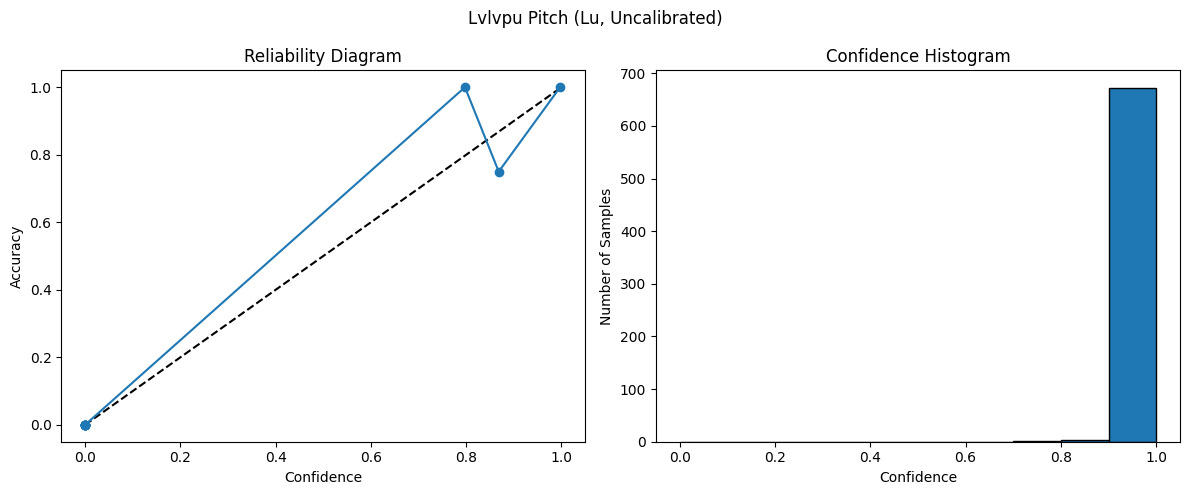

0.0038477317430078983


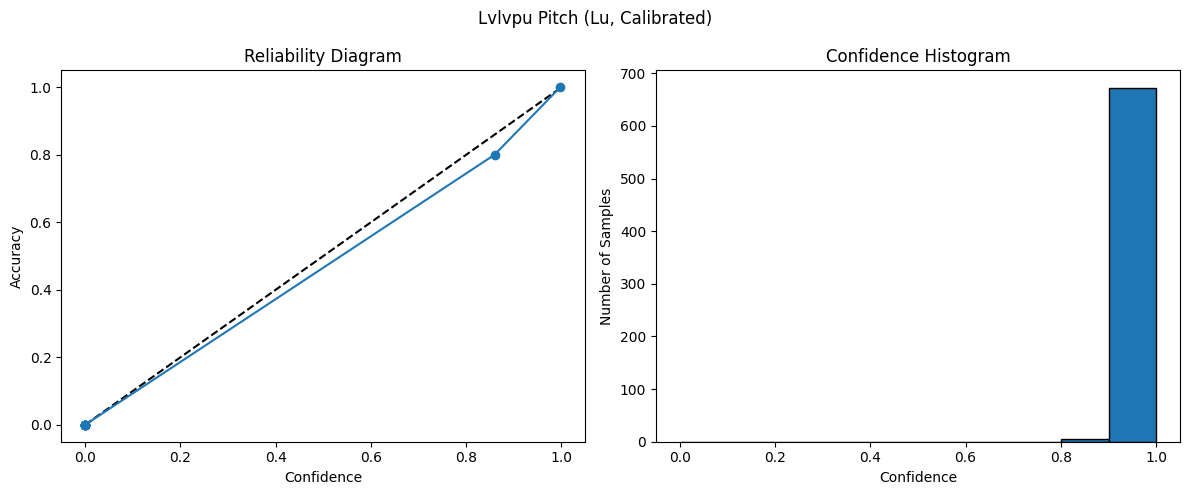

0.003045164281502366


In [14]:
model = TemperatureScalingCalibrationModule(CnnModel(num_classes = 17))
model.load_state_dict(torch.load(f"lvlv_model.std"))

print(model.temperature)

total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, test_edition=best_models["full"]['edition'], is_suzipu=False)
output, labels = predict_data_loader(model, total_dataloaders["full"]["test"], scaled=False)
print(reliability_diagram(output, labels, name="Lvlvpu Pitch (Lu, Uncalibrated)", plot=True)/100)

total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations, test_edition=best_models["full"]['edition'], is_suzipu=False)
output, labels = predict_data_loader(model, total_dataloaders["full"]["test"], scaled=True)
print(reliability_diagram(output, labels, name="Lvlvpu Pitch (Lu, Calibrated)", plot=True)/100)